# Stage 1 — basic version

**Toward Personalized Hebrew ASR** · Dolev Abudi, Hadas Yonat

The minimum needed to answer two questions:

1. How well does each model do **per speaker**?
2. What is each speaker's **adaptation gain** — how much does the Hebrew fine-tune help them?

| | model | inference dump |
|---|---|---|
| **A** | `openai/whisper-large-v3` (general) | `Dolevabudi/voxknesset-whisper-large-v3-baseline` |
| **B** | `ivrit-ai/whisper-large-v3-ct2` (Hebrew fine-tune) | `Dolevabudi/voxknesset-whisper-large-v3-ct2-inference` |

No filtering, no statistics, no modelling — those come later.

---
## 1. Load

In [1]:
import os, re, glob, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rapidfuzz.distance import Levenshtein   # pip install rapidfuzz
from huggingface_hub import snapshot_download

C_A, C_B, C_GAIN = '#0072B2', '#D55E00', '#009E73'   # model A blue, B orange, gain green

C:\Users\hadas\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path_a = snapshot_download('Dolevabudi/voxknesset-whisper-large-v3-baseline',
                           repo_type='dataset', allow_patterns=['data/*'])
path_b = snapshot_download('Dolevabudi/voxknesset-whisper-large-v3-ct2-inference',
                           repo_type='dataset', allow_patterns=['data/*'])

raw_a = pd.concat([pd.read_json(os.path.join(path_a, 'data', f), lines=True)
                   for f in ('train.jsonl', 'test.jsonl')], ignore_index=True)

shards = sorted(p for p in glob.glob(os.path.join(path_b, 'data', '*.parquet'))
                if 'results_10' not in os.path.basename(p))     # skip the 10-row pilot file
raw_b = pd.concat([pd.read_parquet(p) for p in shards], ignore_index=True)

print('A:', raw_a.shape, '| B:', raw_b.shape)
raw_a.head(2)

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Fetching 2 files: 100%|██████████| 2/2 [00:00<00:00, 583.92it/s]

Fetching 71 files:   0%|          | 0/71 [00:00<?, ?it/s]

Fetching 71 files: 100%|██████████| 71/71 [00:00<00:00, 1019.55it/s]

A: (66971, 15) | B: (66670, 15)


,filename,split,audio_seconds,latency_seconds,transcription,reference,error,speaker_id,age,gender,speaker_place_of_birth,speaker_year_of_aliya,speaker_religion,speaker_nationality,speaker_religious_orientation
0,30081_57020_3693_3725.wav,train,31.79,5.94,תודה רבה. תודה רבה לחבר הכנסת יואף קיש. אני לא...,תודה רבה לחבר הכנסת יואב קיש אני לא מבינה למה...,None,30081,54.360001,0,ברית המועצות,1991.0,יהודי,יהודי,חילוני
1,30081_57243_21203_21238.wav,train,34.73,6.93,Thank you very much. Shabbat shalom.,אייכלר חבר הכנסת ישראל אייכלר בבקשה אדוני חמ...,None,30081,54.369999,0,ברית המועצות,1991.0,יהודי,יהודי,חילוני


---
## 2. Pair the two dumps on the same audio

One wrinkle: dump A retried segments whose API call failed, so some filenames appear twice —
once with an error and once with the real transcription. Keep the good attempt.

In [3]:
a = raw_a.copy()
a['good'] = a.error.isna() & a.transcription.fillna('').str.strip().ne('')
a = a.sort_values('good', ascending=False).drop_duplicates('filename')

# Speaker attributes ride along with the segments -- section 10 groups speakers by them.
META = ['age', 'gender', 'speaker_place_of_birth', 'speaker_year_of_aliya',
        'speaker_religion', 'speaker_nationality', 'speaker_religious_orientation']

a = a[['filename', 'speaker_id', 'split', 'audio_seconds', 'reference', 'transcription']
      + META].rename(columns={'audio_seconds': 'duration_s',
                              'reference': 'ref', 'transcription': 'hyp_A'})
b = raw_b[['filename', 'model_transcription']].rename(columns={'model_transcription': 'hyp_B'})

seg = a.merge(b, on='filename', how='inner')
print(f'{len(seg):,} paired segments, {seg.speaker_id.nunique()} speakers, '
      f'{seg.duration_s.sum()/3600:.0f} hours')
seg.head(2)

66,670 paired segments, 393 speakers, 2408 hours


,filename,speaker_id,split,duration_s,ref,hyp_A,age,gender,speaker_place_of_birth,speaker_year_of_aliya,speaker_religion,speaker_nationality,speaker_religious_orientation,hyp_B
0,30081_57020_3693_3725.wav,30081,train,31.79,תודה רבה לחבר הכנסת יואב קיש אני לא מבינה למה...,תודה רבה. תודה רבה לחבר הכנסת יואף קיש. אני לא...,54.360001,0,ברית המועצות,1991.0,יהודי,יהודי,חילוני,תודה רבה. תודה רבה לחבר הכנסת יואב קיש. אני לא...
1,30701_87188_4066_4347.wav,30701,train,281.12,אדוני היושב ראש אדוני השר כנסת נכבדה מאז שהיית...,"בבקשה. אדוני יושב ראש, אדוני השר, כנסת נכבדה. ...",40.060001,1,ישראל,NaN,יהודי,יהודי,חילוני,"בבקשה. אדוני היושב-ראש, אדוני השר, כנסת נכבדה,..."


---
## 3. Normalise the Hebrew text

The protocol references have no punctuation; Whisper outputs punctuated Hebrew. Without this
step we would be scoring typography rather than recognition.

The one rule that is not obvious: geresh `׳` / gershayim `״` become a **space**, because the
protocol writes acronyms spaced out (`רמטכ ל`, `יו ש`). Deleting them instead would fuse two
reference words into one and create an error on every acronym in the corpus.

In [4]:
_niqqud = re.compile(r'[֑-ׇ]')                        # vowel points
_quotes = re.compile(r'[׳״"\'‘’“”]')
_dashes = re.compile(r'[־\-‐-―_/\\]')
_punct  = re.compile(r'[^\w\s֐-׿]', flags=re.UNICODE)

def normalize_he(s):
    if not isinstance(s, str):
        return ''
    s = unicodedata.normalize('NFKC', s)
    s = _niqqud.sub('', s)
    s = _quotes.sub(' ', s)      # -> space, see the note above
    s = _dashes.sub(' ', s)
    s = _punct.sub(' ', s)
    return re.sub(r'\s+', ' ', s).strip()

for src, dst in [('ref', 'ref_n'), ('hyp_A', 'hyp_A_n'), ('hyp_B', 'hyp_B_n')]:
    seg[dst] = seg[src].map(normalize_he)

print('REF :', seg.ref_n.iloc[0][:120])
print('A   :', seg.hyp_A_n.iloc[0][:120])
print('B   :', seg.hyp_B_n.iloc[0][:120])

REF : תודה רבה לחבר הכנסת יואב קיש אני לא מבינה למה יש רעש כזה גדול מצד המחנה הציוני או חברי הכנסת או הצוות נא להירגע בבקשה זה
A   : תודה רבה תודה רבה לחבר הכנסת יואף קיש אני לא מבינה למה יש רעש כזה גדול מצד מחנה הציוני או חברי כנסת או הצוות נע לי רגע ב
B   : תודה רבה תודה רבה לחבר הכנסת יואב קיש אני לא מבינה למה יש רעש כזה גדול מצד המחנה הציוני או החברי הכנסת או הצוות נא להירג


---
## 4. Error counts per segment

WER is the edit distance between the two **word sequences**, divided by the number of reference
words. CER is the same over characters.

We store raw error **counts**, not rates. That matters wherever we aggregate: a speaker's WER is
total errors ÷ total reference words, which is not the same as the average of their segment
WERs — that version would let a 20-word segment count as much as a 500-word one.

Counting here, *before* the filter in §5, is also what lets that section report the corpus WER
with and without the segments it removes.

In [5]:
seg['n_words'] = seg.ref_n.str.split().str.len()
seg['n_chars'] = seg.ref_n.str.len()

for tag in ('A', 'B'):
    hyp = seg[f'hyp_{tag}_n']
    seg[f'werr_{tag}'] = [Levenshtein.distance(r.split(), h.split())
                          for r, h in zip(seg.ref_n, hyp)]
    seg[f'cerr_{tag}'] = [Levenshtein.distance(r, h) for r, h in zip(seg.ref_n, hyp)]
    print(f'model {tag} done')

model A done


model B done


---
## 5. Drop segments whose reference does not match the audio

Some segments pair a long recording with a protocol excerpt covering only a fraction of it. The
worst is a **4.2-hour** file whose reference is **126 words**: the models transcribe the speech
correctly, but almost none of it appears in the reference, so every correctly recognised word is
charged as an insertion.

The filename decodes as `{speaker}_{session}_{start_sec}_{end_sec}.wav`, and a segment is the
contiguous span of session audio the protocol attributes to that speaker. No two speakers' spans
overlap anywhere in the corpus, so **nothing in the metadata can reveal that a file contains more
than one voice**. When the alignment breaks and hands one speaker the remainder of a sitting, the
only visible symptom is a span far too long to be a single turn.

### What not to use: a speaking-rate floor

The obvious test is reference words per minute, but it fails. A segment is a span of *time*, so
it includes the speaker's pauses — a chairman calling the next speaker manages 14 words in 42
seconds, and a rate-based rule discards that as if it were broken. Because the rule is a ratio,
its allowance shrinks to nothing for short references: at a 15 wpm floor, a 3-word reference is
thrown away once the audio passes 12 seconds.

### What we use: unexplained audio

Ask instead how many seconds of recording the reference cannot account for, *assuming the speaker
talks slowly* — 40 words per minute, or 1.5 s per word. Real speech here averages 108 wpm, so the
allowance is deliberately generous.

```
explained_s   = ref_words x 1.5
unexplained_s = duration_s - explained_s      ->  drop if more than 300 s
```

A **flat** 300-second allowance rather than a proportional one is the whole difference. Short
pausey segments keep their slack; a four-hour file holding 126 words does not.

It also tracks the quantity that does the damage. A rate ranks a 2-minute mismatch and a 4-hour
one as nearly the same; `unexplained_s` is, up to a constant, the number of spoken words the
reference fails to cover — which is exactly what gets charged against both models.

Because the error counts already exist (§4), the section closes with a table of the corpus WER
and CER with and without these segments — what the filter costs, and what it buys.

In [6]:
SLOW_WPM     = 40             # generous: real speech in this corpus averages ~108 wpm
SEC_PER_WORD = 60 / SLOW_WPM  # 1.5 s per word
MAX_UNEXPLAINED_S = 300       # 5 minutes of recording with no reference text at all

seg['wpm']           = seg.n_words / (seg.duration_s / 60)   # descriptive only, not the filter
seg['unexplained_s'] = seg.duration_s - seg.n_words * SEC_PER_WORD

print('seconds of audio the reference cannot account for:')
print(seg.unexplained_s.describe(percentiles=[.5, .9, .99, .999]).round(0).to_string())

keep    = seg.unexplained_s <= MAX_UNEXPLAINED_S
dropped = seg[~keep].copy()        # kept aside so the next cells can inspect what went
print(f'\ndropping {(~keep).sum()} of {len(seg):,} segments ({1 - keep.mean():.3%})')
print(f'speakers before: {seg.speaker_id.nunique()}   after: {seg[keep].speaker_id.nunique()}')

display(dropped.sort_values('unexplained_s', ascending=False)
        [['filename', 'duration_s', 'n_words', 'wpm', 'unexplained_s', 'werr_A', 'werr_B']].round(1))

seconds of audio the reference cannot account for:
count    66670.0
mean      -210.0
std        258.0
min      -3339.0
50%       -146.0
90%        -55.0
99%         -6.0
99.9%       80.0
max      33778.0

dropping 14 of 66,670 segments (0.021%)
speakers before: 393   after: 393


,filename,duration_s,n_words,wpm,unexplained_s,werr_A,werr_B
66669,12961_42189_27443_61267.wav,33824.7,31,0.1,33778.2,31,29
66667,30058_94999_5175_20215.wav,15040.1,126,0.5,14851.1,126,9189
66665,30693_85508_973_11567.wav,10593.8,39,0.2,10535.3,39,2
6069,12951_87610_5183_12087.wav,6903.4,103,0.9,6748.9,8939,10146
66668,12951_87610_18371_23419.wav,5047.5,61,0.7,4956.0,61,190
66666,488_61326_4322_7620.wav,3298.4,87,1.6,3168.0,87,16
3893,30660_88666_23424_25412.wav,1988.4,118,3.6,1811.4,71,175
23372,23632_98875_2691_4336.wav,1644.3,67,2.4,1543.8,1246,43
47449,532_79782_2907_3908.wav,1000.9,6,0.4,991.9,1127,70
23333,23632_108969_3136_3945.wav,809.0,11,0.8,792.5,30,2


In [7]:
dropped[dropped['speaker_id'] == 12961]

,filename,speaker_id,split,duration_s,ref,hyp_A,age,gender,speaker_place_of_birth,speaker_year_of_aliya,...,hyp_A_n,hyp_B_n,n_words,n_chars,werr_A,cerr_A,werr_B,cerr_B,wpm,unexplained_s
66669,12961_42189_27443_61267.wav,12961,train,33824.68,את הישיבה היא תתחדש מחר יום רביעי כ ד באייר ...,None,68.449997,1,ארץ ישראל,NaN,...,,הישיבה תתחדש מחר יום רביעי כד באייר התשערה 13 ...,31,147,31,147,29,124,0.054989,33778.18


### What the removal does to the whole dataset

Three rows: the corpus as it arrives, the corpus we keep, and the handful of segments in between.

In [8]:
def corpus_scores(df):
    return pd.Series({
        'segments' : len(df),
        'ref_words': df.n_words.sum(),
        'WER_A'    : df.werr_A.sum() / df.n_words.sum(),
        'WER_B'    : df.werr_B.sum() / df.n_words.sum(),
        'CER_A'    : df.cerr_A.sum() / df.n_chars.sum(),
        'CER_B'    : df.cerr_B.sum() / df.n_chars.sum(),
    })

effect = pd.DataFrame({'before removal'      : corpus_scores(seg),
                       'after removal'       : corpus_scores(seg[keep]),
                       'the dropped segments': corpus_scores(dropped)}).T
effect[['segments', 'ref_words']] = effect[['segments', 'ref_words']].astype(int)
display(effect.round(4))

for tag in ('A', 'B'):
    err_drop, err_all = dropped[f'werr_{tag}'].sum(), seg[f'werr_{tag}'].sum()
    print(f'model {tag}:  {(~keep).mean():.3%} of the segments and '
          f'{dropped.n_words.sum() / seg.n_words.sum():.3%} of the reference words, '
          f'but {err_drop / err_all:.1%} of all word errors '
          f'({err_drop:,} of {err_all:,})')

seg = seg[keep].reset_index(drop=True)
print(f'\nkept {len(seg):,} segments')

,segments,ref_words,WER_A,WER_B,CER_A,CER_B
before removal,66670,15114360,0.2077,0.0998,0.1067,0.0588
after removal,66656,15112843,0.2068,0.0983,0.1058,0.0574
the dropped segments,14,1517,9.2287,14.6473,8.4704,13.5921


model A:  0.021% of the segments and 0.010% of the reference words, but 0.4% of all word errors (14,000 of 3,138,796)
model B:  0.021% of the segments and 0.010% of the reference words, but 1.5% of all word errors (22,220 of 1,508,180)

kept 66,656 segments


**Reading it.** The corpus WER hardly moves — 0.2077 → 0.2068 for model A, 0.0998 → 0.0983 for
model B. Fourteen segments holding 1,517 of 15.1 million reference words cannot shift an average,
and no filter working at this scale could.

The third row is where the damage shows. Those segments score a WER of **9.2** for A and **14.6**
for B — errors outnumber reference words nine- and fifteen-fold, because the models transcribe
speech the protocol excerpt never mentions and every such word is charged as an insertion. WER is
not bounded by 1 for exactly this reason. They hold 0.010% of the reference words but carry 0.4%
of model A's word errors and 1.5% of model B's: a 40-fold and 150-fold over-representation.

The two models are hit unevenly, and the 4.2-hour file of speaker 30058 shows why — model A
returned nothing at all for it (126 deletions, the entire reference) while model B transcribed
the speech in full (9,189 errors). B also has only half as large a total error budget to absorb
such a hit.

So the filter is not here to improve the headline WER — it cannot. It is here because these
errors are not spread thinly over the corpus but concentrated in a handful of speakers, where
they are large enough to invert that speaker's result. §8 shows one such case.

---
## 6. Overall, before looking at speakers

In [9]:
for tag, name in [('A', 'whisper-large-v3 (general)'), ('B', 'ivrit-ai whisper-large-v3 (FT)')]:
    wer = seg[f'werr_{tag}'].sum() / seg.n_words.sum()
    cer = seg[f'cerr_{tag}'].sum() / seg.n_chars.sum()
    print(f'{name:<34}  WER {wer:.4f}   CER {cer:.4f}')

whisper-large-v3 (general)          WER 0.2068   CER 0.1058
ivrit-ai whisper-large-v3 (FT)      WER 0.0983   CER 0.0574


---
## 7. Performance per speaker

The same calculation, grouped by speaker.

In [10]:
spk = seg.groupby('speaker_id').agg(
    n_seg   = ('filename', 'size'),
    hours   = ('duration_s', lambda s: s.sum() / 3600),
    n_words = ('n_words', 'sum'),
    n_chars = ('n_chars', 'sum'),
    werr_A  = ('werr_A', 'sum'), werr_B = ('werr_B', 'sum'),
    cerr_A  = ('cerr_A', 'sum'), cerr_B = ('cerr_B', 'sum'),
)
for tag in ('A', 'B'):
    spk[f'wer_{tag}'] = spk[f'werr_{tag}'] / spk.n_words
    spk[f'cer_{tag}'] = spk[f'cerr_{tag}'] / spk.n_chars
spk = spk.drop(columns=[c for c in spk.columns if 'err_' in c])

print(f'{len(spk)} speakers')
spk[['n_seg', 'hours', 'wer_A', 'wer_B', 'cer_A', 'cer_B']].describe().round(3)

393 speakers


,n_seg,hours,wer_A,wer_B,cer_A,cer_B
count,393.000,393.000,393.000,393.000,393.000,393.000
mean,169.608,6.068,0.213,0.098,0.111,0.057
std,232.371,7.507,0.094,0.029,0.078,0.021
min,1.000,0.017,0.097,0.033,0.034,0.012
25%,34.000,1.248,0.164,0.079,0.077,0.044
50%,90.000,3.368,0.197,0.095,0.096,0.054
75%,218.000,8.210,0.239,0.114,0.124,0.067
max,1810.000,65.849,1.270,0.242,1.051,0.188


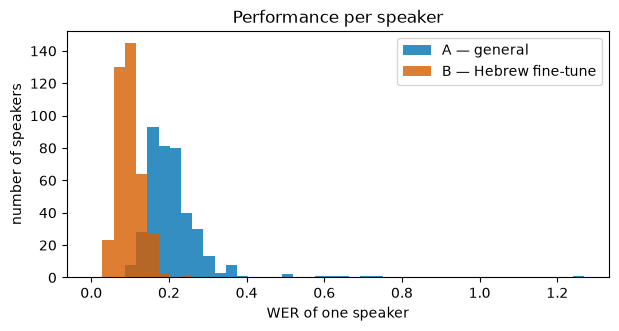

In [11]:
fig, ax = plt.subplots(figsize=(7, 3.2))
bins = np.linspace(0, spk.wer_A.max(), 45)
ax.hist(spk.wer_A, bins=bins, color=C_A, alpha=0.8, label='A — general')
ax.hist(spk.wer_B, bins=bins, color=C_B, alpha=0.8, label='B — Hebrew fine-tune')
ax.set_xlabel('WER of one speaker'); ax.set_ylabel('number of speakers')
ax.set_title('Performance per speaker'); ax.legend()
plt.show()

---
## 8. Adaptation gain per speaker

How much does the Hebrew fine-tune help each individual?

* `gain_abs` = WER_A − WER_B — WER points recovered
* `gain_rel` = gain_abs / WER_A — the fraction of the original error removed

In [12]:
spk['gain_abs'] = spk.wer_A - spk.wer_B
spk['gain_rel'] = spk.gain_abs / spk.wer_A

print(f'speakers helped by the fine-tune : {(spk.gain_abs > 0).sum()} / {len(spk)}')
print(f'speakers hurt by it              : {(spk.gain_abs < 0).sum()} / {len(spk)}')
print(f'median relative gain             : {spk.gain_rel.median():.1%}')
spk[['wer_A', 'wer_B', 'gain_abs', 'gain_rel']].describe().round(3)

speakers helped by the fine-tune : 393 / 393
speakers hurt by it              : 0 / 393
median relative gain             : 51.7%


,wer_A,wer_B,gain_abs,gain_rel
count,393.000,393.000,393.000,393.000
mean,0.213,0.098,0.115,0.524
std,0.094,0.029,0.082,0.086
min,0.097,0.033,0.047,0.186
25%,0.164,0.079,0.083,0.476
50%,0.197,0.095,0.099,0.517
75%,0.239,0.114,0.123,0.560
max,1.270,0.242,1.174,0.924


> **What the §5 filter bought.** Without it, speaker 30058 shows a `gain_rel` of **−1.70** and
> appears to be *hurt* by the fine-tune. The whole effect came from that one 4.2-hour segment:
> model B transcribed 9,293 words of real speech the 126-word protocol excerpt does not cover,
> and every one counted as an insertion — 82% of the speaker's total errors from a single
> segment. Model A only "won" there because its transcription of it was empty.
>
> With the filter that speaker is unremarkable: WER 0.171 → 0.086, a 50% gain like everyone
> else, and no speaker in the corpus is hurt by the fine-tune.

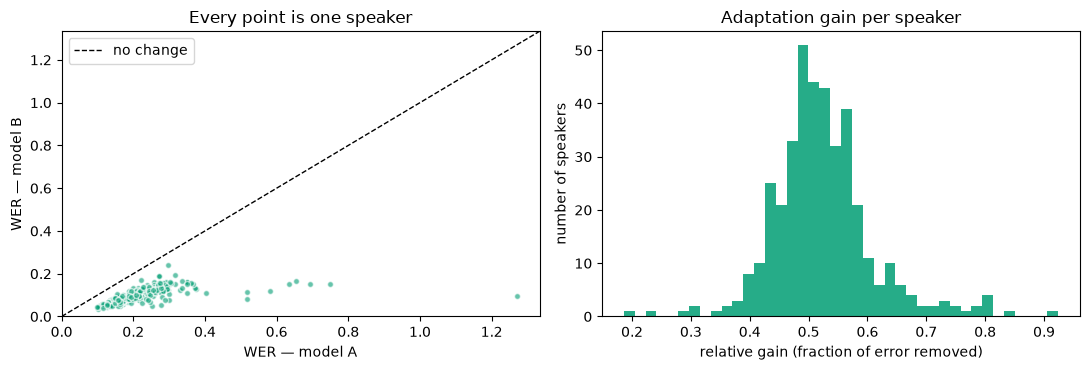

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

ax = axes[0]
lim = [0, spk.wer_A.max() * 1.05]
ax.plot(lim, lim, 'k--', lw=1, label='no change')
ax.scatter(spk.wer_A, spk.wer_B, s=18, color=C_GAIN, alpha=0.6, edgecolor='white')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('WER — model A'); ax.set_ylabel('WER — model B')
ax.set_title('Every point is one speaker'); ax.legend()

ax = axes[1]
ax.hist(spk.gain_rel, bins=40, color=C_GAIN, alpha=0.85)
ax.set_xlabel('relative gain (fraction of error removed)')
ax.set_ylabel('number of speakers'); ax.set_title('Adaptation gain per speaker')
plt.tight_layout(); plt.show()

### Who gains most, and who gains least

Watch `n_seg` here — a speaker with only a handful of segments can land at either end of this
list by chance rather than for any real reason.

In [14]:
cols = ['n_seg', 'hours', 'wer_A', 'wer_B', 'gain_abs', 'gain_rel']
print('--- largest gain ---')
display(spk.nlargest(10, 'gain_rel')[cols].round(3))
print('--- smallest gain ---')
display(spk.nsmallest(10, 'gain_rel')[cols].round(3))

--- largest gain ---


,n_seg,hours,wer_A,wer_B,gain_abs,gain_rel
speaker_id,,,,,,
3263,2,0.214,1.270,0.096,1.174,0.924
10555,29,1.150,0.518,0.082,0.435,0.841
29855,1,0.056,0.252,0.050,0.201,0.800
448,123,6.411,0.748,0.150,0.599,0.800
30787,10,0.819,0.276,0.056,0.220,0.799
30816,9,0.649,0.582,0.118,0.465,0.798
12962,61,1.814,0.693,0.151,0.542,0.783
30095,40,1.803,0.517,0.113,0.404,0.782
22911,2,0.188,0.635,0.153,0.481,0.758


--- smallest gain ---


,n_seg,hours,wer_A,wer_B,gain_abs,gain_rel
speaker_id,,,,,,
30789,7,0.412,0.298,0.242,0.055,0.186
4298,13,0.563,0.222,0.170,0.052,0.235
30767,8,0.382,0.271,0.190,0.080,0.296
1033,38,1.357,0.270,0.187,0.083,0.307
30745,13,0.555,0.153,0.106,0.047,0.308
30698,3,0.200,0.199,0.132,0.067,0.338
30716,15,0.460,0.189,0.121,0.068,0.360
12936,294,9.523,0.212,0.134,0.078,0.367
464,17,0.739,0.257,0.161,0.096,0.373


---
## 9. WER against the amount of data per speaker

Does having more speech from a speaker go with better recognition? `n_seg` and `hours` measure
almost the same thing here (rho ≈ 0.98), so both panels should agree.

Note this is **not** about training data — no model was trained on these speakers as part of
this project. It asks whether prolific speakers are recognised differently, and it doubles as a
check on how much of the per-speaker spread is just measurement noise.

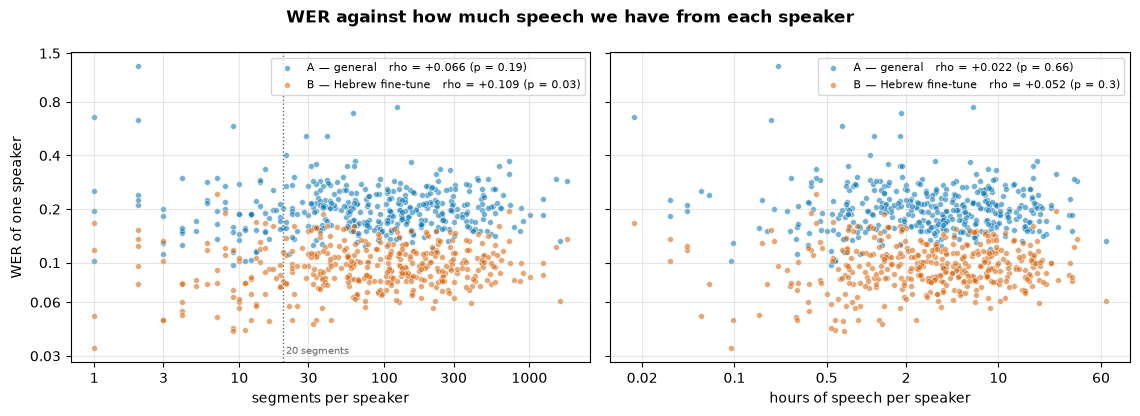

In [15]:
from scipy import stats
import matplotlib.ticker as mticker

def rho(x, y):
    r = stats.spearmanr(x, y)
    return r.statistic, r.pvalue

def decimal_log_axis(ax, ticks):
    ax.set_xscale('log')
    ax.xaxis.set_major_locator(mticker.FixedLocator(ticks))
    ax.xaxis.set_minor_locator(mticker.NullLocator())
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:g}'))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=True)

for ax, col, label, ticks, cut in [
        (axes[0], 'n_seg', 'segments per speaker', [1, 3, 10, 30, 100, 300, 1000], 20),
        (axes[1], 'hours', 'hours of speech per speaker', [0.02, 0.1, 0.5, 2, 10, 60], None)]:
    for tag, colour, name in [('A', C_A, 'A — general'), ('B', C_B, 'B — Hebrew fine-tune')]:
        r, p = rho(spk[col], spk[f'wer_{tag}'])
        ax.scatter(spk[col], spk[f'wer_{tag}'], s=18, color=colour, alpha=0.55,
                   edgecolor='white', linewidth=0.6,
                   label=f'{name}   rho = {r:+.3f} (p = {p:.2g})')
    if cut is not None:                      # a segment count, so only meaningful on the left
        ax.axvline(cut, color='0.4', ls=':', lw=1)
        ax.text(cut, 0.02, f' {cut} segments', transform=ax.get_xaxis_transform(),
                fontsize=7.5, color='0.4', va='bottom')
    decimal_log_axis(ax, ticks)
    ax.set_yscale('log')
    ax.yaxis.set_major_locator(mticker.FixedLocator([0.03, 0.06, 0.1, 0.2, 0.4, 0.8, 1.5]))
    ax.yaxis.set_minor_locator(mticker.NullLocator())
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:g}'))
    ax.set_xlabel(label); ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('WER of one speaker')
fig.suptitle('WER against how much speech we have from each speaker',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

In [16]:
# The visible funnel: does the SPREAD shrink with more data, while the LEVEL stays flat?
bucket = pd.cut(spk.n_seg, [0, 5, 20, 50, 150, 400, 2000],
                labels=['1-5', '6-20', '21-50', '51-150', '151-400', '400+'])
tbl = spk.groupby(bucket, observed=True).agg(
    speakers=('wer_A', 'size'),
    median_wer_A=('wer_A', 'median'), sd_wer_A=('wer_A', 'std'),
    median_wer_B=('wer_B', 'median'), sd_wer_B=('wer_B', 'std'))
display(tbl.round(4))

,speakers,median_wer_A,sd_wer_A,median_wer_B,sd_wer_B
n_seg,,,,,
1-5,20,0.1889,0.2776,0.0764,0.0389
6-20,49,0.1865,0.0793,0.0833,0.0409
21-50,68,0.2089,0.0767,0.0956,0.0316
51-150,120,0.1923,0.0822,0.0939,0.0243
151-400,91,0.1983,0.0491,0.0958,0.0236
400+,45,0.2029,0.0583,0.0995,0.0255


### Reading it

**The level is flat.** Median WER barely moves across the buckets, and the correlations are near
zero. How much speech we have from a speaker does not predict how well either model does on
them.

**The spread is not flat.** The standard deviation of `wer_A` falls from about 0.28 among
speakers with 1–5 segments to about 0.06 among those with 400+. That funnel is the plot's real
content, and it is a **measurement** effect, not a property of the speakers: a WER computed on
two segments is mostly noise, and one computed on 400 is not.

That is what the dotted line at 20 segments marks, and why any statistical claim here
should be restricted to speakers above it. It is also why the extreme values in
this notebook's tables — the speaker at WER 1.27, the one-segment speaker with a 75% gain — sit
on the far left of these panels and should not be read as findings about those people.

---
## 10. Subgroups — who could share a fine-tune?

Stage 2's sharing axis trains three ways — **personal-only**, **subgroup-only**, and
**subgroup-then-personal** — to ask whether personalization adds anything beyond group
membership. That needs a subgroup *definition*, and Stage 1 is where we decide which
definitions are worth spending GPU hours on.

A definition has to clear two bars, and they are independent:

1. **Enough data to train on.** A subgroup with four speakers and 90 minutes between them cannot
   support a subgroup-only arm. What matters is the speech available from the *other* members,
   since the target speaker is held out — so we report hours with the largest member removed.
2. **Actual separation.** If speakers in a group do not resemble each other in how the models
   treat them, pooling their audio is unlikely to transfer. A rule that splits the corpus into
   groups with identical error and identical gain is not a subgroup rule, it is a random split.

The plan names three families of definition: **demographic** (place of birth, year of aliya,
religion, nationality, religious orientation, age, gender), **behavioural** (Stage-1 error
profile, or speaking rate), and **acoustic** (x-vector / ECAPA distance). Only the first two are
reachable from these dumps — acoustic similarity needs the audio.

One family member is deliberately absent: grouping by **Stage-1 error profile** and then testing
whether that separates gain is circular, since gain is computed from the same error rates. Speaking
rate stands in as the behavioural rule.

In [17]:
# ---- speaker attributes, and the subgroup rules built from them ----------------
def clean(s):
    return s.astype(str).str.strip().replace({'nan': np.nan, 'None': np.nan, '': np.nan})

ORIGIN = {
    'ישראל': 'Israel', 'ארץ ישראל': 'Israel',
    'ברית המועצות': 'FSU', 'האימפריה הרוסית': 'FSU',
    'אנגליה': 'Europe', 'בלגיה': 'Europe', 'גרמניה': 'Europe', 'פולין': 'Europe',
    'צרפת': 'Europe', 'רומניה': 'Europe',
    'איראן': 'MENA', "אלג'יריה": 'MENA', 'מצרים': 'MENA', 'מרוקו': 'MENA', 'סוריה': 'MENA',
    'עיראק': 'MENA', 'תוניסיה': 'MENA', 'טורקיה': 'MENA',
    'ארגנטינה': 'Americas', 'ארצות הברית': 'Americas', 'קנדה': 'Americas', 'מקסיקו': 'Americas',
    'אתיופיה': 'Ethiopia',
}
NATION   = {'יהודי': 'Jewish', 'ערבי': 'Arab', 'דרוזי': 'Druze', 'בדואי': 'Bedouin'}
RELIGION = {'יהודי': 'Jewish', 'מוסלמי': 'Muslim', 'דרוזי': 'Druze', 'נוצרי': 'Christian'}
ORIENT   = {'חילוני': 'Secular', 'דתי': 'Religious', 'חרדי': 'Haredi',
            'סוני': 'Sunni', 'יווני-קתולי': 'Greek-Catholic'}

attrs = seg.groupby('speaker_id').agg(
    age_mean    = ('age', 'mean'),
    gender_code = ('gender', 'first'),
    place_birth = ('speaker_place_of_birth', 'first'),
    religion_he = ('speaker_religion', 'first'),
    nation_he   = ('speaker_nationality', 'first'),
    orient_he   = ('speaker_religious_orientation', 'first'),
    wpm_median  = ('wpm', 'median'),
)
attrs['gender']      = np.where(attrs.gender_code == 1, 'Male', 'Female')
attrs['origin']      = clean(attrs.place_birth).map(ORIGIN).fillna('Unknown')
attrs['nationality'] = clean(attrs.nation_he).map(NATION).fillna('Unknown')
attrs['religion']    = clean(attrs.religion_he).map(RELIGION).fillna('Unknown')
attrs['orientation'] = clean(attrs.orient_he).map(ORIENT).fillna('Unrecorded')
attrs['age_band']    = pd.qcut(attrs.age_mean, 4,
                               labels=['age Q1 (youngest)', 'age Q2', 'age Q3', 'age Q4 (oldest)'])
attrs['rate_band']   = pd.qcut(attrs.wpm_median, 3,
                               labels=['slow speech', 'medium speech', 'fast speech'])

# per-speaker error totals, so a subgroup's WER can pool words rather than average rates
totals = seg.groupby('speaker_id').agg(werr_A=('werr_A', 'sum'), werr_B=('werr_B', 'sum'),
                                       words=('n_words', 'sum'))
G = spk.join(totals).join(attrs)

# The subgroup rules. Edit this dict -- Stage 2 treats the definition as a config parameter.
RULES = {
    'gender':                 'gender',
    'nationality':            'nationality',
    'religion':               'religion',
    'religious orientation':  'orientation',
    'country of origin':      'origin',
    'age quartile':           'age_band',
    'speaking rate tertile':  'rate_band',
}
for name, col in RULES.items():
    print(f'{name:<24} {G[col].nunique():>2} groups   ' + ', '.join(
        f'{k}={v}' for k, v in G[col].value_counts().items()))

gender                    2 groups   Male=290, Female=103
nationality               5 groups   Jewish=342, Arab=31, Druze=13, Bedouin=6, Unknown=1
religion                  5 groups   Jewish=342, Muslim=32, Druze=13, Christian=5, Unknown=1
religious orientation     6 groups   Secular=164, Unrecorded=120, Religious=64, Haredi=43, Greek-Catholic=1, Sunni=1
country of origin         7 groups   Israel=306, FSU=32, MENA=23, Americas=12, Europe=9, Ethiopia=9, Unknown=2
age quartile              4 groups   age Q1 (youngest)=99, age Q2=98, age Q3=98, age Q4 (oldest)=98
speaking rate tertile     3 groups   slow speech=131, medium speech=131, fast speech=131


### 10.1 Is there enough data to train on?

`hours_minus_largest` is the speech left in a subgroup once its biggest speaker is held out —
the worst case for a subgroup-only arm, where the target must not be in their own training set.

The thresholds below are placeholders keyed to the Stage 2 budget axis (which tops out at 80
minutes per speaker); a subgroup arm wants comfortably more than one speaker's budget.

In [18]:
MIN_SPEAKERS = 3       # fewer than this is not a group
MIN_HOURS    = 5.0     # hours available after holding out the largest member

def subgroup_table(col):
    t = G.groupby(col, observed=True).agg(
        speakers=('n_seg', 'size'), segments=('n_seg', 'sum'),
        hours=('hours', 'sum'), words=('words', 'sum'),
        eA=('werr_A', 'sum'), eB=('werr_B', 'sum'), largest=('hours', 'max'))
    t['wer_A']    = t.eA / t.words
    t['wer_B']    = t.eB / t.words
    t['gain_abs'] = t.wer_A - t.wer_B
    t['gain_rel'] = t.gain_abs / t.wer_A
    t['hours_minus_largest'] = t.hours - t.largest
    t['stage2_viable'] = (t.speakers >= MIN_SPEAKERS) & (t.hours_minus_largest >= MIN_HOURS)
    return t[['speakers', 'segments', 'hours', 'hours_minus_largest',
              'wer_A', 'wer_B', 'gain_abs', 'gain_rel', 'stage2_viable']].sort_values('wer_B',
                                                                                      ascending=False)

for name, col in RULES.items():
    print(f'\n===== {name} =====')
    display(subgroup_table(col).round({'hours': 1, 'hours_minus_largest': 1, 'wer_A': 4,
                                       'wer_B': 4, 'gain_abs': 4, 'gain_rel': 3}))


===== gender =====


,speakers,segments,hours,hours_minus_largest,wer_A,wer_B,gain_abs,gain_rel,stage2_viable
gender,,,,,,,,,
Male,290,53911,1877.7,1811.8,0.2132,0.1006,0.1126,0.528,True
Female,103,12745,507.0,485.2,0.1834,0.0902,0.0933,0.508,True



===== nationality =====


,speakers,segments,hours,hours_minus_largest,wer_A,wer_B,gain_abs,gain_rel,stage2_viable
nationality,,,,,,,,,
Unknown,1,1,0.0,0.0,0.6538,0.1667,0.4872,0.745,False
Bedouin,6,800,27.6,19.2,0.2836,0.1276,0.1560,0.550,True
Druze,13,1492,50.3,33.0,0.2688,0.1186,0.1503,0.559,True
Arab,31,7461,266.9,231.8,0.2260,0.1094,0.1166,0.516,True
Jewish,342,56902,2040.0,1974.1,0.2024,0.0963,0.1061,0.524,True



===== religion =====


...

,speakers,segments,hours,hours_minus_largest,wer_A,wer_B,gain_abs,gain_rel,stage2_viable
origin,,,,,,,,,
Ethiopia,9,742,30.1,18.8,0.2748,0.1292,0.1457,0.530,True
Europe,9,1782,63.5,44.0,0.2572,0.1178,0.1394,0.542,True
FSU,32,5146,176.0,138.4,0.2611,0.1132,0.1479,0.566,True
MENA,23,3648,132.8,113.3,0.2218,0.1056,0.1162,0.524,True
Israel,306,54066,1936.7,1870.8,0.1982,0.0955,0.1027,0.518,True
Americas,12,1124,38.4,26.5,0.2026,0.0946,0.1079,0.533,True
Unknown,2,148,7.3,0.0,0.2046,0.0833,0.1213,0.593,False



===== age quartile =====


,speakers,segments,hours,hours_minus_largest,wer_A,wer_B,gain_abs,gain_rel,stage2_viable
age_band,,,,,,,,,
age Q4 (oldest),98,19066,678.5,639.1,0.2244,0.1013,0.1230,0.548,True
age Q3,98,20314,725.8,659.9,0.2110,0.1013,0.1097,0.520,True
age Q2,98,14176,511.8,477.5,0.2027,0.0970,0.1058,0.522,True
age Q1 (youngest),99,13100,468.6,432.4,0.1815,0.0916,0.0899,0.495,True



===== speaking rate tertile =====


,speakers,segments,hours,hours_minus_largest,wer_A,wer_B,gain_abs,gain_rel,stage2_viable
rate_band,,,,,,,,,
fast speech,131,20982,739.3,710.9,0.2023,0.1006,0.1017,0.503,True
slow speech,131,19606,713.3,675.7,0.2228,0.0998,0.1229,0.552,True
medium speech,131,26068,932.1,866.2,0.2001,0.0953,0.1048,0.524,True


### 10.2 Does the rule actually separate the speakers?

Two panels per rule: **relative gain** and **absolute gain**, one dot per speaker, each subgroup
in its own colour. The bar is the group median, the vertical line its interquartile range, and
the dashed line the corpus median.

What to look for: groups sitting at visibly different heights with tight spread. Groups stacked
on top of each other mean the rule carries no information about how the models behave, and
pooling their audio has no reason to transfer.

Two restrictions apply here that do **not** apply to the viability table above, because the two
sections ask different questions. §10.1 asks how much audio a group has, so every speaker counts.
This section asks whether group membership predicts an outcome, so:

* **speakers with fewer than 20 segments are excluded** — §9 showed their WER is largely sampling
  noise, and noise on the outcome only blurs whatever separation exists;
* **`Unknown` and `Unrecorded` are dropped** — they are missing metadata, not groups. Leaving
  them in would silently test whether *having* a recorded birthplace predicts adaptation gain,
  which is a different question and not one Stage 2 can act on.

separation analysis uses speakers with >= 20 segments, in groups of >= 3, excluding ['Unknown', 'Unrecorded']

  gender                   326 of 393 speakers, 2 groups
  nationality              326 of 393 speakers, 4 groups
  religion                 326 of 393 speakers, 4 groups
  religious orientation    234 of 393 speakers, 3 groups
  country of origin        325 of 393 speakers, 6 groups
  age quartile             326 of 393 speakers, 4 groups
  speaking rate tertile    326 of 393 speakers, 3 groups


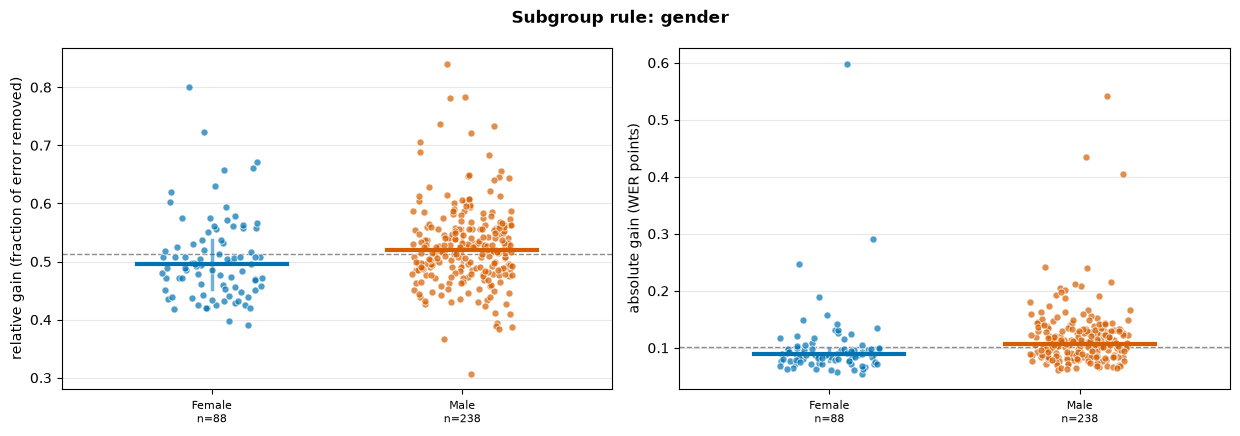

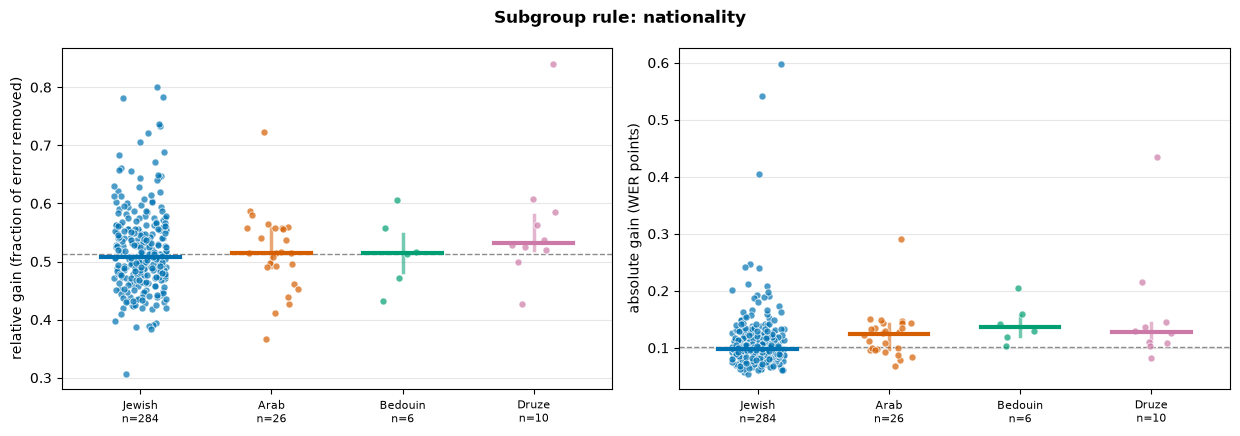

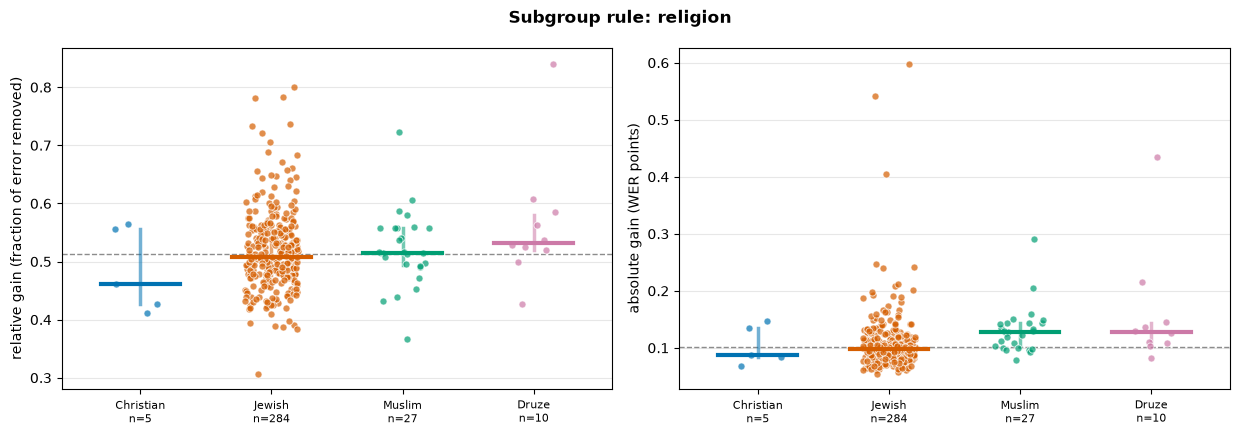

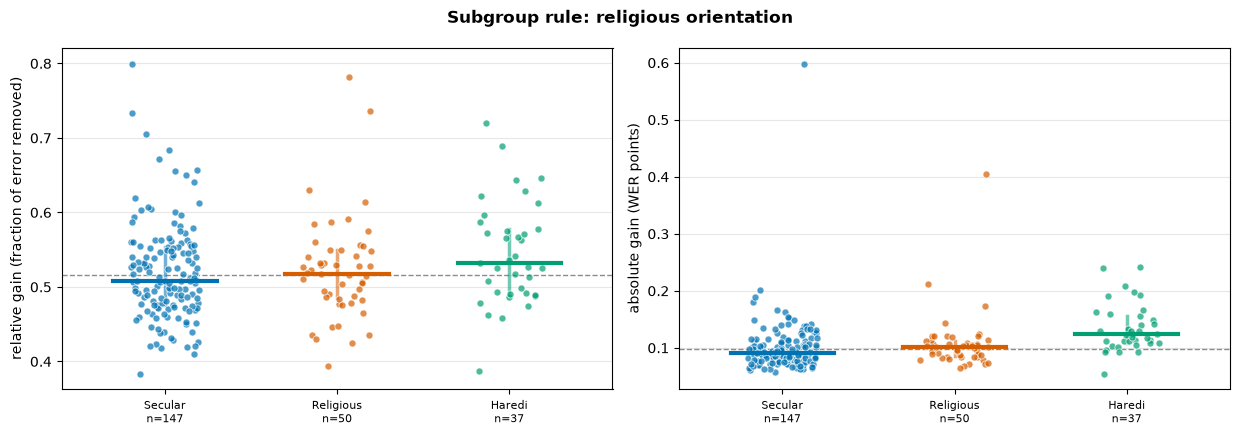

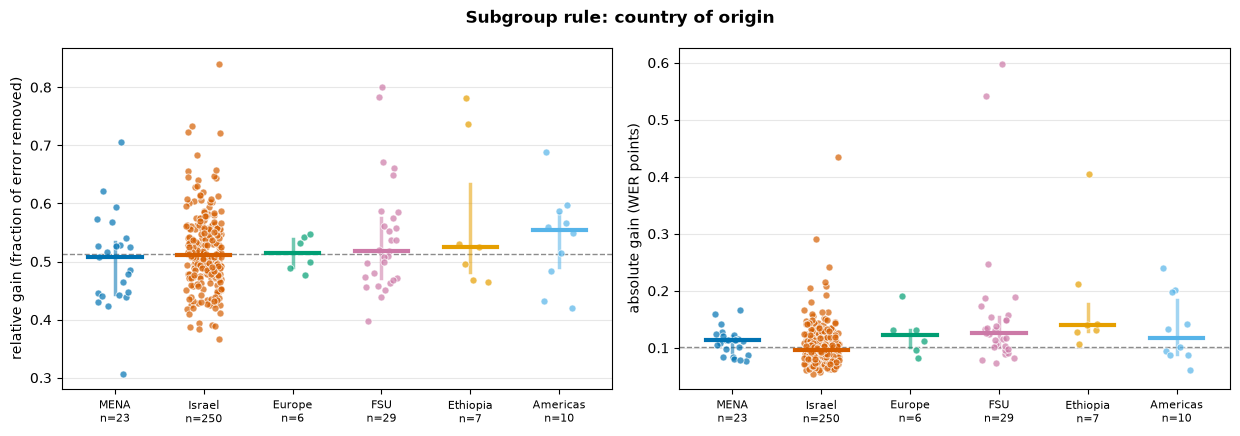

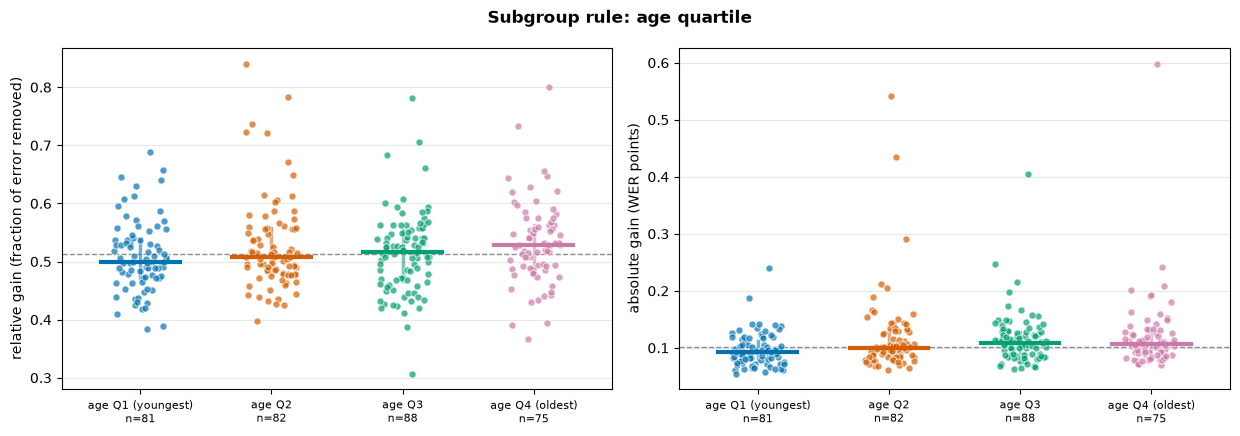

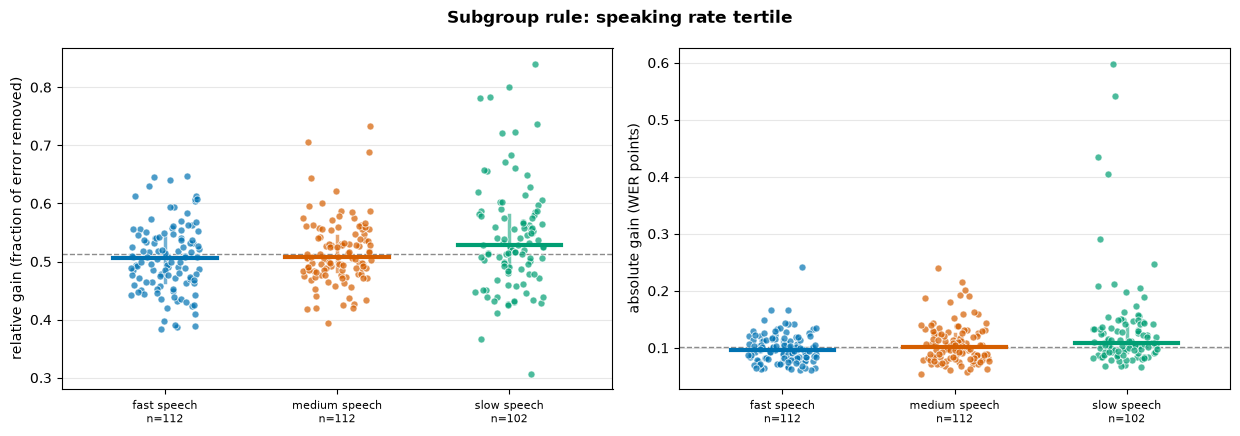

In [19]:
# Okabe-Ito: colour-vision-deficiency safe, assigned in fixed order and never cycled.
PALETTE = ['#0072B2', '#D55E00', '#009E73', '#CC79A7',
           '#E69F00', '#56B4E9', '#8B4513', '#555555']

MIN_SEG_FOR_SEPARATION = 20
NOT_A_GROUP = {'Unknown', 'Unrecorded'}

# Speakers reliable enough to carry a subgroup signal, in genuine groups only.
def separation_set(col):
    d = G[(G.n_seg >= MIN_SEG_FOR_SEPARATION) & (~G[col].astype(str).isin(NOT_A_GROUP))]
    counts = d[col].value_counts()
    return d[d[col].isin(counts[counts >= 3].index)]      # a group needs at least 3 speakers

print(f'separation analysis uses speakers with >= {MIN_SEG_FOR_SEPARATION} segments, '
      f'in groups of >= 3, excluding {sorted(NOT_A_GROUP)}\n')
for name, col in RULES.items():
    d = separation_set(col)
    print(f'  {name:<24} {len(d):>3} of {len(G)} speakers, {d[col].nunique()} groups')

def separation_plot(name, col):
    d = separation_set(col)
    order = d.groupby(col, observed=True).gain_rel.median().sort_values().index.tolist()[:len(PALETTE)]
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
    rng_j = np.random.default_rng(0)
    for ax, ycol, ylab in [(axes[0], 'gain_rel', 'relative gain (fraction of error removed)'),
                           (axes[1], 'gain_abs', 'absolute gain (WER points)')]:
        ax.axhline(d[ycol].median(), color='0.55', ls='--', lw=1, zorder=1)
        for k, gname in enumerate(order):
            v = d.loc[d[col] == gname, ycol].dropna().values
            if not len(v):
                continue
            x = k + rng_j.uniform(-0.20, 0.20, len(v))
            ax.scatter(x, v, s=26, color=PALETTE[k], alpha=0.70,
                       edgecolor='white', linewidth=0.7, zorder=3)
            q1, med, q3 = np.percentile(v, [25, 50, 75])
            ax.plot([k, k], [q1, q3], color=PALETTE[k], lw=2.5, alpha=0.55, zorder=2)
            ax.plot([k - 0.30, k + 0.30], [med, med], color=PALETTE[k], lw=3, zorder=4)
        ax.set_xticks(range(len(order)))
        ax.set_xticklabels([f'{g}\nn={(d[col] == g).sum()}' for g in order], fontsize=8)
        ax.set_ylabel(ylab)
        ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)
        ax.set_xlim(-0.6, len(order) - 0.4)
    fig.suptitle(f'Subgroup rule: {name}', fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

for name, col in RULES.items():
    separation_plot(name, col)

### 10.3 Ranking the rules

Eyeballing seven pairs of panels is not a decision procedure. **Eta squared** is the share of the
variance in a speaker-level outcome that sits *between* subgroups rather than within them — 0
means the rule tells you nothing, 1 means group membership determines the outcome.

Eta squared is biased upward when groups are small and numerous, so a rule with six groups is not
comparable to one with two on the raw number. The null column fixes that: shuffle the subgroup
labels across speakers, recompute, and report the 95th percentile. Anything below its own null is
noise dressed as structure.

In [20]:
def eta_squared(labels, y):
    d = pd.DataFrame({'g': labels, 'y': y}).dropna()
    grand = d.y.mean()
    ss_tot = ((d.y - grand) ** 2).sum()
    if ss_tot == 0:
        return np.nan
    ss_between = d.groupby('g', observed=True).y.apply(
        lambda s: len(s) * (s.mean() - grand) ** 2).sum()
    return ss_between / ss_tot

def separation_stats(col, ycol, n_perm=2000, rng=np.random.default_rng(0)):
    d = separation_set(col)[[col, ycol]].dropna()      # same speakers as the plots above
    obs = eta_squared(d[col], d[ycol])
    null = np.array([eta_squared(rng.permutation(d[col].values), d[ycol].values)
                     for _ in range(n_perm)])
    return obs, np.percentile(null, 95), (null >= obs).mean(), len(d)

rows = []
for name, col in RULES.items():
    row = {'rule': name, 'groups': separation_set(col)[col].nunique()}
    for ycol in ('gain_rel', 'wer_B'):
        obs, null95, p, n = separation_stats(col, ycol)
        row['speakers'] = n
        row[f'eta2 {ycol}'] = obs
        row[f'null95 {ycol}'] = null95
        row[f'p {ycol}'] = p
    rows.append(row)

rank = pd.DataFrame(rows).set_index('rule').sort_values('eta2 gain_rel', ascending=False)
rank['separates gain?'] = np.where(rank['p gain_rel'] < 0.05, 'yes', 'no')
rank['separates WER?']  = np.where(rank['p wer_B'] < 0.05, 'yes', 'no')
rank = rank[['groups', 'speakers',
             'eta2 gain_rel', 'null95 gain_rel', 'p gain_rel', 'separates gain?',
             'eta2 wer_B', 'null95 wer_B', 'p wer_B', 'separates WER?']]
display(rank.round(4))

,groups,speakers,eta2 gain_rel,null95 gain_rel,p gain_rel,separates gain?,eta2 wer_B,null95 wer_B,p wer_B,separates WER?
rule,,,,,,,,,,
speaking rate tertile,3,326,0.0423,0.0176,0.0010,yes,0.0112,0.0175,0.1555,no
country of origin,6,325,0.0272,0.0367,0.1260,no,0.1063,0.0348,0.0000,yes
religious orientation,3,234,0.0181,0.0257,0.1295,no,0.0906,0.0264,0.0000,yes
gender,2,326,0.0178,0.0119,0.0175,yes,0.0179,0.0116,0.0090,yes
age quartile,4,326,0.0166,0.0247,0.1545,no,0.0414,0.0242,0.0025,yes
religion,4,326,0.0154,0.0248,0.1755,no,0.0470,0.0243,0.0015,yes
nationality,4,326,0.0117,0.0239,0.2790,no,0.0545,0.0242,0.0005,yes


### 10.4 Reading it

**Data volume is not the binding constraint — separation is.** Every genuine demographic group
clears the viability bar, including the smallest ones: Ethiopia (9 speakers, 30 h, 19 h with the
largest member held out), Europe (9, 64 h, 44 h) and Bedouin (6, 28 h, 19 h). The only rows that
fail are the metadata-missing pseudo-groups — `Unknown`, and the single-speaker `Sunni` and
`Greek-Catholic` cells — which were never subgroups to begin with. So the question is entirely
whether a rule separates anything.

**The two outcomes come apart, and this is the section's main result.**

| | separates `wer_B` (how hard the speaker is) | separates `gain_rel` (how much adaptation helps) |
|---|---|---|
| country of origin | **yes** — eta² 0.106, the strongest rule here | no (p = 0.13) |
| religious orientation | **yes** — eta² 0.091 | no (p = 0.13) |
| nationality | **yes** — eta² 0.055 | no (p = 0.28) |
| religion | **yes** — eta² 0.047 | no (p = 0.18) |
| age quartile | **yes** — eta² 0.041 | no (p = 0.15) |
| gender | yes — eta² 0.018 | yes — eta² 0.018 |
| speaking rate | no (p = 0.16) | **yes** — eta² 0.042, the strongest here |

Demographic membership predicts **who the models find difficult**, and predicts it clearly — origin
alone accounts for about 11% of the between-speaker variance in post-fine-tune WER. But none of
those rules predicts **who benefits from adaptation**. The only rule that separates gain is the
behavioural one, speaking rate, and gender at the edge.

That matters directly for Stage 2's sharing axis. Pooling a subgroup by country of origin gathers
speakers who are *similarly hard*, not speakers who *adapt similarly*. If `subgroup-only` and
`subgroup-then-personal` are meant to work because group members share whatever adaptation
learns, this evidence says demographic membership is not that thing. That is the useful negative
result the plan anticipated, and it strengthens the case for the acoustic (x-vector / ECAPA)
family — the one definition family Stage 1 cannot reach, because it needs the audio.

**Keep the effect sizes in view.** The best rule explains about 11% of the variance in `wer_B` and
the best gain rule about 4%. Roughly 90% of the variation is *within* groups in every case. These
are real but weak, and a subgroup arm built on any of them is pooling speakers who differ from
each other far more than their groups differ from one another.

**A methodological note worth carrying to the report.** Run on all 393 speakers with the
metadata-missing rows left in, origin, religion and nationality all appeared to separate gain at
p < 0.05. Both effects vanished once §10.2's restrictions were applied. The apparent signal came
from speakers with a handful of segments — whose gain is mostly sampling noise, as §9 showed —
and from `Unknown` behaving like a group when it is really an absence of data. It is the same
lesson as §9: decide what the null is and who is eligible *before* reading the statistic.

**If one sharing cell is all Tier 1 affords**, country of origin is the defensible pick: it
separates final performance most strongly, and its non-Israel groups carry enough audio to train
on (FSU 32 speakers / 176 h, MENA 23 / 133 h). It also aligns with the panel — the speakers with
the highest `wer_B` are disproportionately FSU-, Ethiopia- and Arabic-background — so the subgroup
arm would be pooling speakers who plausibly share an accent, which is the mechanism the sharing
hypothesis actually rests on.

---
## 11. Save

In [21]:
os.makedirs('outputs_basic', exist_ok=True)
spk.to_csv('outputs_basic/speaker_performance.csv', encoding='utf-8-sig')
print('wrote outputs_basic/speaker_performance.csv', spk.shape)
spk.head()

wrote outputs_basic/speaker_performance.csv (393, 10)


,n_seg,hours,n_words,n_chars,wer_A,cer_A,wer_B,cer_B,gain_abs,gain_rel
speaker_id,,,,,,,,,,
427,151,7.843186,45846,238595,0.254526,0.120564,0.105418,0.056041,0.149108,0.585826
433,38,1.436064,10527,52750,0.202147,0.106142,0.082075,0.048948,0.120072,0.593985
435,65,2.898922,13751,73767,0.216202,0.108951,0.101883,0.065178,0.114319,0.528759
445,578,18.296294,119053,622228,0.191184,0.094570,0.094353,0.057979,0.096831,0.506480
448,123,6.411167,34131,181924,0.748381,0.622853,0.149717,0.075773,0.598664,0.799945


---
## What this version deliberately leaves out

Each of these is a real issue. The point of stopping here is to see the basic numbers first.

* **only one filter** — §5 catches references that do not match their audio, but nothing checks
  the *transcription*; a decoder that loops and repeats a phrase is still counted in full
* **no minimum segment count** — some speakers have only one or two segments, so their WER is
  mostly noise. The highest speaker WER in the table comes from a speaker with **2 segments**,
  and is not a real result about that person
* **no variance or significance testing** — is the spread across speakers real, and does it
  differ between the two models?
* **no covariates** — age, gender, origin, speaking rate
* **the digit problem** — the protocol writes `שמונה`, Whisper writes `8`, and that counts as
  an error against both models